# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 3
- **Date:** 26/07/2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-03"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib, datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
751bde0816dfb3a4c877193b6dc9d71345e884a5e2c931c58d2c64dcb7ce5a8d


# Experiment Details

## Objective

To study and implement **Simple Logistic Regression (SiLR)** and **Multiple Logistic Regression (MuLR)**  
using the *Bank Marketing* dataset  
(UCI ML Repository, ID: 222), in order to predict whether a bank client will **subscribe to a term deposit**  
(binary target: 1 = Yes / subscribed, 0 = No / not subscribed), and to compare the classification  
performance of both models using standard metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC).

---

## Theory

**Classification** is a supervised machine learning task where the goal is to assign a discrete  
class label to each input. **Logistic Regression** is the standard linear model for binary  
classification — it estimates the *probability* that an observation belongs to class 1 (subscribed).

**1. Simple Logistic Regression (SiLR)** uses a single predictor $x$ to model the log-odds:

$$\log\frac{P(y=1)}{1-P(y=1)} = \beta_0 + \beta_1 x$$

which is equivalent to:

$$P(y=1) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

where $\sigma(\cdot)$ is the **sigmoid (logistic) function** that maps any real value into $(0,1)$.

**2. Multiple Logistic Regression (MuLR)** extends this to $p$ predictors:

$$P(y=1) = \sigma\left(\beta_0 + \sum_{j=1}^{p} \beta_j x_j\right)$$

Parameters are estimated by **maximum likelihood estimation (MLE)** — maximising the log-likelihood  
using iterative solvers (L-BFGS).

**Decision boundary:** A predicted probability $\geq 0.5$ is classified as Subscribed (1); below 0.5 as Not Subscribed (0).

**Why this dataset?** The Bank Marketing dataset represents a real-world telemarketing classification  
problem with 45,211 instances and 16 mixed-type features (numerical + categorical). It is a  
well-established benchmark for evaluating classifiers on **imbalanced** binary targets —  
only ~11.7% of clients subscribe, making the class imbalance a key modelling challenge.

**Class Imbalance:** With ~88% 'No' and ~12% 'Yes', a naive classifier that always predicts  
'No' achieves ~88% accuracy but is completely useless. Hence, **Precision, Recall, F1-Score,  
and ROC-AUC** are more informative than raw accuracy here.

**Feature Engineering:** The dataset contains categorical variables (job, marital, education,  
contact, month, poutcome, etc.) that must be numerically encoded before fitting a Logistic  
Regression model. We use **Label Encoding** for binary categories and  
**One-Hot Encoding** for multi-class categories.

**Regularisation (L2 / Ridge):** Logistic Regression in scikit-learn includes an L2 penalty  
controlled by $C = 1/\lambda$. A smaller $C$ applies stronger regularisation, reducing overfitting —  
important given the large number of one-hot-encoded dummy variables.

**Note on `duration` feature:** The `duration` variable (last call duration in seconds) is a  
highly predictive feature — if duration = 0, the outcome is always 'No'. However, this value  
is only known *after* the call ends, making it a potential **data leakage** variable in  
production models. We include it here for academic benchmarking purposes as the dataset  
providers themselves note this.

**Evaluation Metrics:**
- **Accuracy** — fraction of correct predictions: $\frac{TP+TN}{TP+TN+FP+FN}$
- **Precision** — of all predicted subscribers, how many actually subscribed: $\frac{TP}{TP+FP}$
- **Recall (Sensitivity)** — of all actual subscribers, how many were caught: $\frac{TP}{TP+FN}$
- **F1-Score** — harmonic mean of Precision and Recall: $2 \cdot \frac{P \cdot R}{P+R}$
- **ROC-AUC** — area under the Receiver Operating Characteristic curve; 1.0 = perfect, 0.5 = random

---

## Dataset

- **Name:** Bank Marketing
- **Source:** UCI Machine Learning Repository (ID: 222)  
  — https://archive.ics.uci.edu/dataset/222/bank+marketing
- **Reference:** Moro, S., Rita, P., & Cortez, P. (2014). *A data-driven approach to predict the  
  success of bank telemarketing.* Decision Support Systems.
- **Total Instances:** 45,211 (using bank-full.csv)
- **Features (16):** age, job, marital, education, default, balance, housing, loan,  
  contact, day, month, duration, campaign, pdays, previous, poutcome
- **Target:** y — has the client subscribed a term deposit? (yes → 1, no → 0)
- **Class Distribution:** ~88.3% No (not subscribed), ~11.7% Yes (subscribed) — **imbalanced**
- **Missing Values:** None (some features have 'unknown' as a categorical level)
- **Task Type:** Binary Classification
- **Licence:** CC BY 4.0

---

# Data Loading & Preprocessing

In [3]:
# Step 1 — Import required libraries
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io, ssl, urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI Bank Marketing dataset (ID: 222)
# Primary method : ucimlrepo (official UCI Python package)
# Fallback method: GitHub-hosted mirror of bank-full.csv

try:
    from ucimlrepo import fetch_ucirepo
    bank_marketing = fetch_ucirepo(id=222)
    X_raw = bank_marketing.data.features.copy()
    y_raw = bank_marketing.data.targets.copy()
    df_raw = pd.concat([X_raw, y_raw], axis=1)
    df_raw.rename(columns={"y": "y"}, inplace=True)
    print("Dataset loaded via ucimlrepo (official UCI package).")

except Exception:
    # Fallback: GitHub mirror (same data as UCI bank-full.csv)
    MIRROR_URL = (
        "https://raw.githubusercontent.com/dsrscientist/dataset1/"
        "master/bank-full.csv"
    )
    ctx = ssl._create_unverified_context()
    with urllib.request.urlopen(MIRROR_URL, context=ctx) as resp:
        raw_bytes = resp.read().decode()
    df_raw = pd.read_csv(io.StringIO(raw_bytes), sep=";")
    print("Dataset loaded via GitHub mirror (fallback).")

print(f"Shape  : {df_raw.shape}")
print(df_raw.head(3))

Dataset loaded via ucimlrepo (official UCI package).
Shape  : (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  


In [5]:
# Step 3 — Dataset overview

print("Dataset : Bank Marketing")
print("Samples :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])
print("Source  : UCI ML Repository (ID: 222)")
print("Target  : y  (yes = 1 — subscribed, no = 0 — not subscribed)")

Dataset : Bank Marketing
Samples : 45211
Columns : 17
Source  : UCI ML Repository (ID: 222)
Target  : y  (yes = 1 — subscribed, no = 0 — not subscribed)


In [6]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw.head(5))

Shape: (45211, 17)

Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3    

In [7]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes.value_counts())
print("\nUnique values per column:")
print(df_raw.nunique())
print("\nTarget unique values:", df_raw["y"].unique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB

Data Types:
str      10
int64     7
Name: count, dtype: int64

Unique values per

In [8]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())

# Note: 'unknown' appears as a categorical level in several columns — not a true NaN
print("\nColumns containing 'unknown' category:")
for col in df_raw.select_dtypes(include="object").columns:
    n_unk = (df_raw[col] == "unknown").sum()
    if n_unk > 0:
        print(f"  {col}: {n_unk} rows ({n_unk/len(df_raw)*100:.2f}%)")

Missing values per column:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

Total missing values: 52124

Columns containing 'unknown' category:


C:\Users\shrri\AppData\Local\Temp\ipykernel_10644\943380210.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_raw.select_dtypes(include="object").columns:


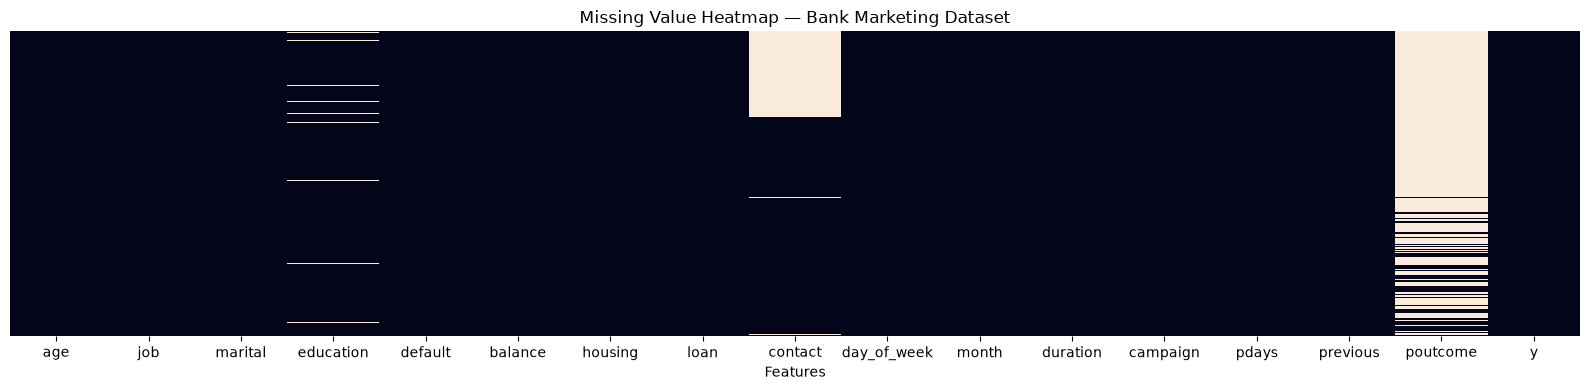

In [9]:
# Step 7 — Visualise missing values

plt.figure(figsize=(16, 4))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap — Bank Marketing Dataset")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

In [10]:
# Step 8 — Check and remove duplicate rows

dup_count = df_raw.duplicated().sum()
print("Duplicate rows:", dup_count)

df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Shape after cleaning: (45211, 17)


In [11]:
# Step 9 — Descriptive statistics (numeric features only)

desc = df.describe().T
print(desc.to_string())

               count         mean          std     min    25%    50%     75%       max
age          45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0      95.0
balance      45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0  102127.0
day_of_week  45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0      31.0
duration     45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0    4918.0
campaign     45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0      63.0
pdays        45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0     871.0
previous     45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0     275.0


Class Distribution:
   Count  Percentage (%)
y                       
0  39922            88.3
1   5289            11.7


C:\Users\shrri\AppData\Local\Temp\ipykernel_10644\1948277961.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y", data=df,


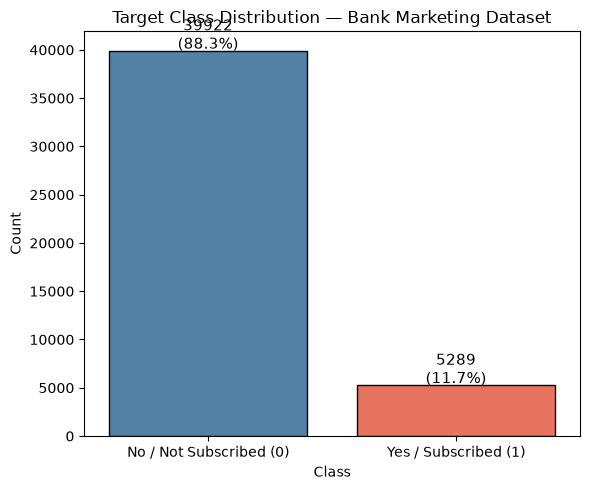


Note: Dataset is IMBALANCED — ~88% No vs ~12% Yes.
Accuracy alone is NOT a reliable metric here. Use F1-Score and ROC-AUC.


In [12]:
# Step 10 — Target class distribution

# Encode target: yes -> 1, no -> 0
df["y"] = df["y"].map({"yes": 1, "no": 0})

counts = df["y"].value_counts().sort_index()
pct    = df["y"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution:")
print(pd.DataFrame({"Count": counts, "Percentage (%)": pct.round(2)}))

plt.figure(figsize=(6, 5))
sns.countplot(x="y", data=df,
              palette=["steelblue", "tomato"], edgecolor="black",
              order=[0, 1])
plt.xticks([0, 1], ["No / Not Subscribed (0)", "Yes / Subscribed (1)"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Class Distribution — Bank Marketing Dataset")
for i, (cls, v) in enumerate(counts.items()):
    plt.text(i, v + 200, f"{v}\n({pct[cls]:.1f}%)", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("\nNote: Dataset is IMBALANCED — ~88% No vs ~12% Yes.")
print("Accuracy alone is NOT a reliable metric here. Use F1-Score and ROC-AUC.")

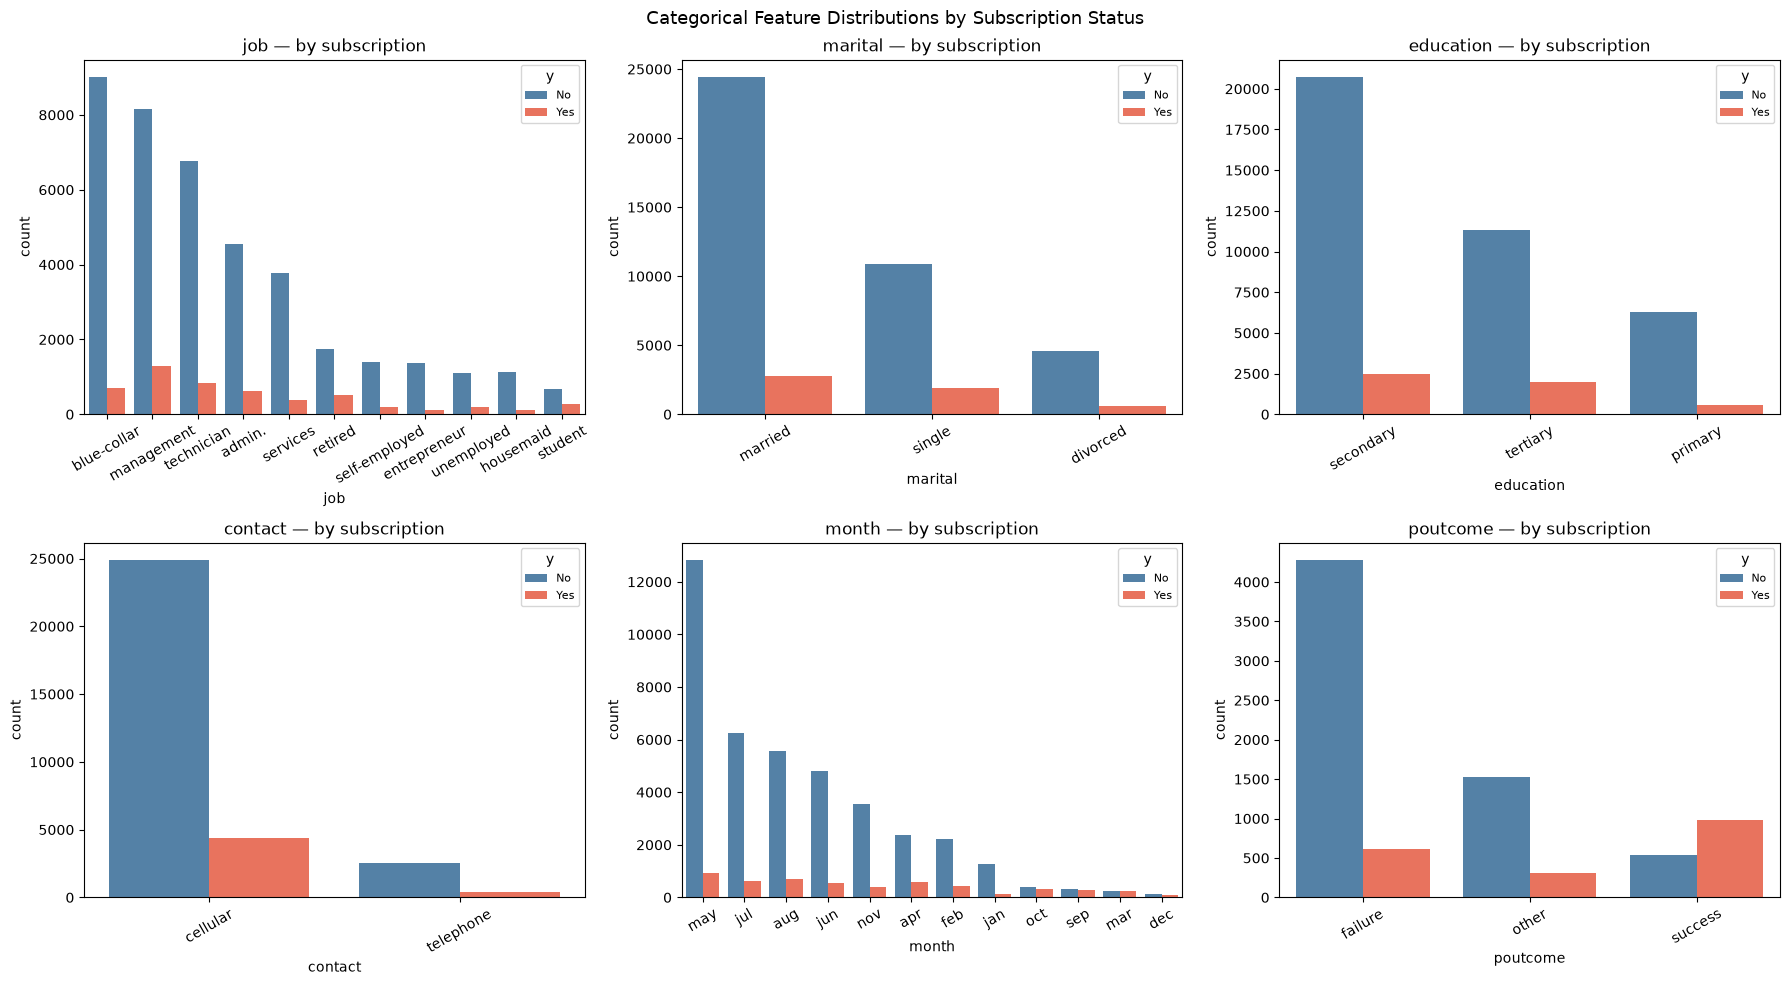

In [13]:
# Step 11 — Categorical feature distributions

cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue="y", data=df, ax=ax,
                  order=order,
                  palette={0: "steelblue", 1: "tomato"})
    ax.set_title(f"{col} — by subscription")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="y", labels=["No", "Yes"], fontsize=8)

plt.suptitle("Categorical Feature Distributions by Subscription Status", fontsize=13)
plt.tight_layout()
plt.show()

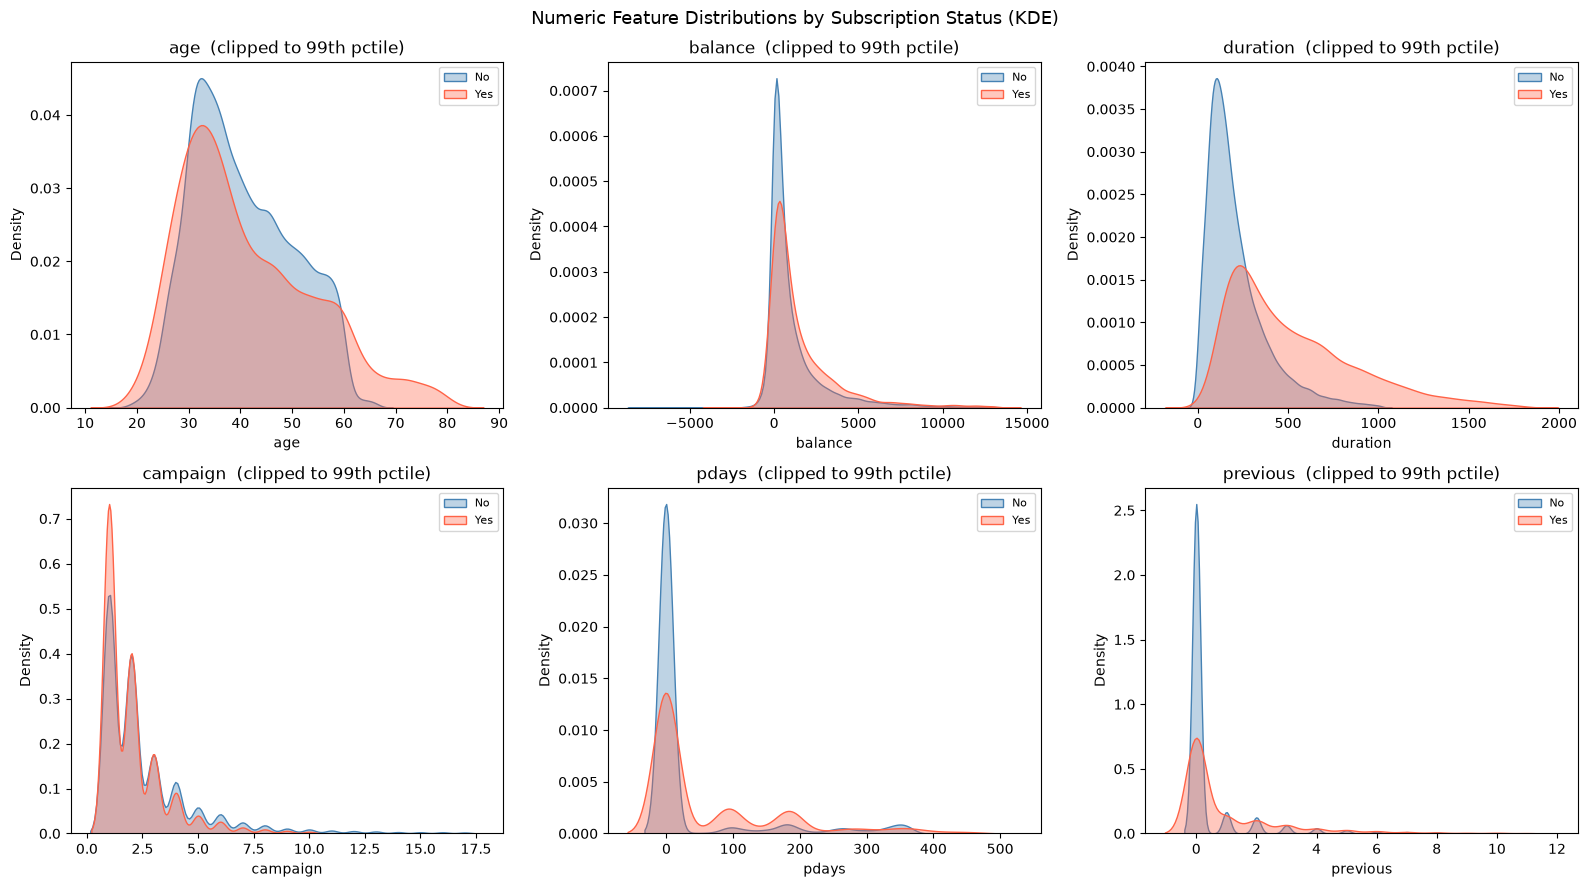

In [14]:
# Step 12 — Numeric feature distributions: Subscribed vs Not Subscribed

num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    for cls, color, label in [(0, "steelblue", "No"), (1, "tomato", "Yes")]:
        data_cls = df[df["y"] == cls][col]
        # Clip extreme outliers for clarity
        q99 = data_cls.quantile(0.99)
        sns.kdeplot(data_cls[data_cls <= q99], ax=ax,
                    color=color, label=label, fill=True, alpha=0.35)
    ax.set_title(f"{col}  (clipped to 99th pctile)")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions by Subscription Status (KDE)", fontsize=13)
plt.tight_layout()
plt.show()

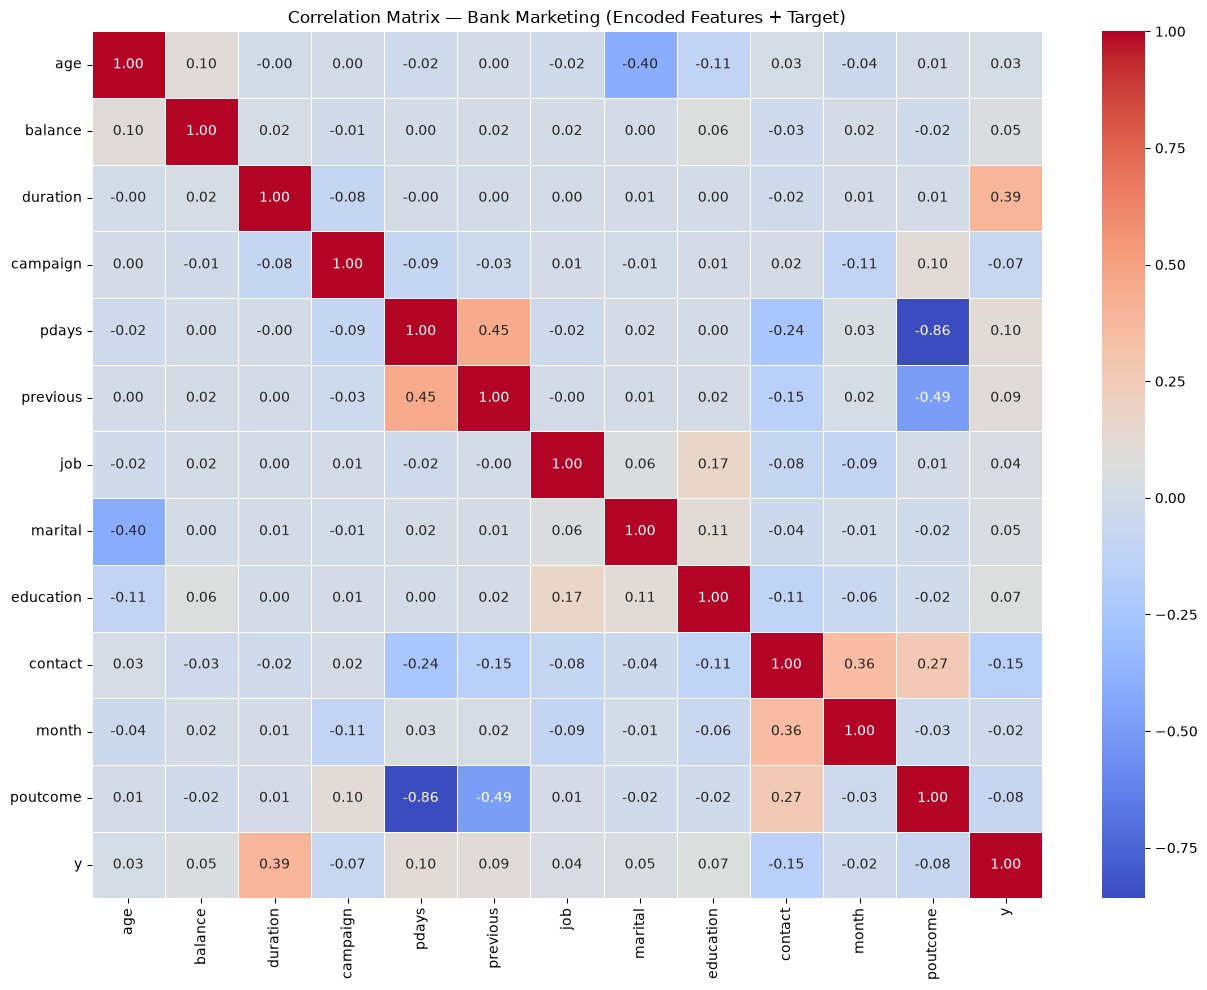


Correlation with target (y) — sorted by absolute value:
duration     0.394521
contact      0.148395
pdays        0.103621
previous     0.093236
poutcome     0.077840
campaign     0.073172
education    0.066241
balance      0.052838
marital      0.045588
job          0.040438
age          0.025155
month        0.024471
Name: y, dtype: float64


In [15]:
# Step 13 — Encode categorical features and compute correlation matrix

# Encode all categoricals for the correlation heatmap
df_enc_corr = df.copy()

# Binary categoricals — simple map
binary_map = {"yes": 1, "no": 0, "unknown": np.nan}
for col in ["default", "housing", "loan"]:
    df_enc_corr[col] = df_enc_corr[col].map(binary_map)

# Multi-class categoricals — label encode (ordinal enough for correlation)
le = LabelEncoder()
for col in ["job", "marital", "education", "contact", "month", "poutcome"]:
    df_enc_corr[col] = le.fit_transform(df_enc_corr[col].astype(str))

corr_cols = ["age", "balance", "duration", "campaign", "pdays",
             "previous", "job", "marital", "education",
             "contact", "month", "poutcome", "y"]

plt.figure(figsize=(13, 10))
sns.heatmap(df_enc_corr[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.4)
plt.title("Correlation Matrix — Bank Marketing (Encoded Features + Target)")
plt.tight_layout()
plt.show()

print("\nCorrelation with target (y) — sorted by absolute value:")
corr_with_y = df_enc_corr[corr_cols].corr()["y"].drop("y").abs().sort_values(ascending=False)
print(corr_with_y)

---
# Implementation

## Part A — Simple Logistic Regression (SiLR)

Use only the **single most discriminative numeric feature** — the feature with the highest  
absolute correlation with the target `y` (typically `duration` — last call duration in seconds).  
This mirrors the SLR → SiLR progression from Lab 2 (Sonar).

In [16]:
# Step 14 — Identify best single numeric feature and train Simple Logistic Regression

# Use the label-encoded version of the dataset for all modelling steps
df_model = df_enc_corr.copy()
df_model.dropna(inplace=True)              # drop rows where binary encoding created NaN
df_model.reset_index(drop=True, inplace=True)

feature_cols = [c for c in df_model.columns if c != "y"]
y_all = df_model["y"]

# Best single feature: highest |correlation| with y
corr_with_target = df_model[feature_cols].corrwith(df_model["y"]).abs()
best_feature     = corr_with_target.idxmax()
print(f"Best single feature (highest |correlation| with target): {best_feature}")
print(f"Correlation value: {corr_with_target[best_feature]:.4f}")
print()
print("Top 5 features by |correlation|:")
print(corr_with_target.sort_values(ascending=False).head(5))

X_simple = df_model[[best_feature]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_all, test_size=0.20, random_state=42, stratify=y_all
)

scaler_s     = StandardScaler()
X_train_s_sc = scaler_s.fit_transform(X_train_s)
X_test_s_sc  = scaler_s.transform(X_test_s)

slr_model = LogisticRegression(C=1.0, max_iter=500, random_state=42)
slr_model.fit(X_train_s_sc, y_train_s)

y_pred_s = slr_model.predict(X_test_s_sc)
y_prob_s = slr_model.predict_proba(X_test_s_sc)[:, 1]

acc_s  = accuracy_score(y_test_s, y_pred_s)
prec_s = precision_score(y_test_s, y_pred_s, zero_division=0)
rec_s  = recall_score(y_test_s, y_pred_s, zero_division=0)
f1_s   = f1_score(y_test_s, y_pred_s, zero_division=0)
auc_s  = roc_auc_score(y_test_s, y_prob_s)

print(f"\n=== SIMPLE LOGISTIC REGRESSION RESULTS ({best_feature} only) ===")
print(f"Equation : log-odds = {slr_model.intercept_[0]:.4f} + "
      f"{slr_model.coef_[0][0]:.4f} × {best_feature} (scaled)")
print(f"Accuracy  : {acc_s:.4f}")
print(f"Precision : {prec_s:.4f}")
print(f"Recall    : {rec_s:.4f}")
print(f"F1-Score  : {f1_s:.4f}")
print(f"ROC-AUC   : {auc_s:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s,
                             target_names=["Not Subscribed", "Subscribed"]))

Best single feature (highest |correlation| with target): duration
Correlation value: 0.3945

Top 5 features by |correlation|:
duration    0.394521
contact     0.148395
housing     0.139173
pdays       0.103621
previous    0.093236
dtype: float64

=== SIMPLE LOGISTIC REGRESSION RESULTS (duration only) ===
Equation : log-odds = -2.2842 + 0.9171 × duration (scaled)
Accuracy  : 0.8870
Precision : 0.5698
Recall    : 0.1389
F1-Score  : 0.2234
ROC-AUC   : 0.8069

Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.90      0.99      0.94      7985
    Subscribed       0.57      0.14      0.22      1058

      accuracy                           0.89      9043
     macro avg       0.73      0.56      0.58      9043
  weighted avg       0.86      0.89      0.86      9043



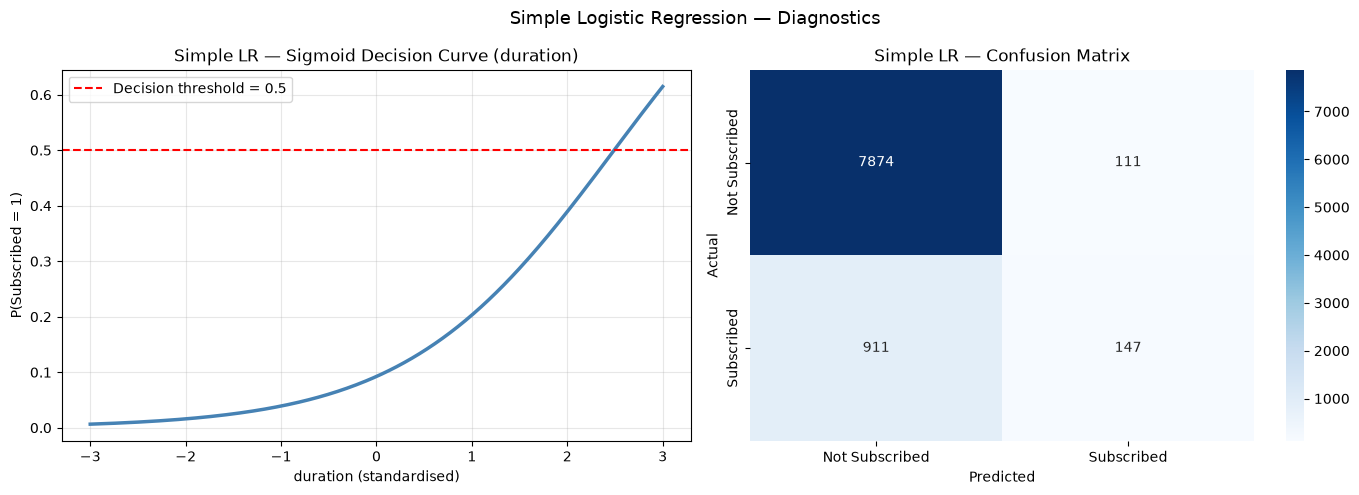

In [17]:
# Step 15 — Sigmoid decision curve and Confusion Matrix (SiLR)

x_range    = np.linspace(-3, 3, 300).reshape(-1, 1)
prob_curve = slr_model.predict_proba(x_range)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid curve
axes[0].plot(x_range, prob_curve, color="steelblue", linewidth=2.5)
axes[0].axhline(0.5, color="red", linestyle="--", label="Decision threshold = 0.5")
axes[0].set_xlabel(f"{best_feature} (standardised)")
axes[0].set_ylabel("P(Subscribed = 1)")
axes[0].set_title(f"Simple LR — Sigmoid Decision Curve ({best_feature})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Confusion Matrix
cm_s = confusion_matrix(y_test_s, y_pred_s)
sns.heatmap(cm_s, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Subscribed", "Subscribed"],
            yticklabels=["Not Subscribed", "Subscribed"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Simple LR — Confusion Matrix")

plt.suptitle("Simple Logistic Regression — Diagnostics", fontsize=13)
plt.tight_layout()
plt.show()

## Part B — Multiple Logistic Regression (MuLR)

Use **all 16 features** (after encoding) with L2 regularisation to classify bank clients.  
Feature scaling is mandatory because numeric features span very different ranges  
(e.g., `balance` in thousands of euros vs `campaign` in single digits).

In [18]:
# Step 16 — Feature engineering and preprocessing for MuLR

X_all = df_model[feature_cols]

print("Features used for MuLR:")
print(feature_cols)
print(f"\nTotal features  : {len(feature_cols)}")
print(f"Total instances : {len(X_all)}")
print(f"Class balance — Not Subscribed (0): {(y_all==0).sum()}  "
      f"|  Subscribed (1): {(y_all==1).sum()}")
print(f"Class ratio     : {(y_all==1).sum()/(y_all==0).sum():.3f}  "
      f"(1 subscriber for every "
      f"{(y_all==0).sum()/(y_all==1).sum():.1f} non-subscribers)")

Features used for MuLR:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Total features  : 16
Total instances : 45211
Class balance — Not Subscribed (0): 39922  |  Subscribed (1): 5289
Class ratio     : 0.132  (1 subscriber for every 7.5 non-subscribers)


In [19]:
# Step 17 — Train Multiple Logistic Regression model

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# C=0.1 applies stronger L2 regularisation — important with many features and class imbalance
# class_weight='balanced' adjusts loss weights inversely proportional to class frequencies
mlr_model = LogisticRegression(
    C=0.1, max_iter=1000, solver="lbfgs",
    class_weight="balanced", random_state=42
)
mlr_model.fit(X_train_sc, y_train)

y_pred_m = mlr_model.predict(X_test_sc)
y_prob_m = mlr_model.predict_proba(X_test_sc)[:, 1]

acc_m  = accuracy_score(y_test, y_pred_m)
prec_m = precision_score(y_test, y_pred_m, zero_division=0)
rec_m  = recall_score(y_test, y_pred_m, zero_division=0)
f1_m   = f1_score(y_test, y_pred_m, zero_division=0)
auc_m  = roc_auc_score(y_test, y_prob_m)

print("=== MULTIPLE LOGISTIC REGRESSION RESULTS (all features, balanced weights) ===")
print(f"Accuracy  : {acc_m:.4f}")
print(f"Precision : {prec_m:.4f}")
print(f"Recall    : {rec_m:.4f}")
print(f"F1-Score  : {f1_m:.4f}")
print(f"ROC-AUC   : {auc_m:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_m,
                             target_names=["Not Subscribed", "Subscribed"]))

=== MULTIPLE LOGISTIC REGRESSION RESULTS (all features, balanced weights) ===
Accuracy  : 0.8090
Precision : 0.3586
Recall    : 0.8015
F1-Score  : 0.4955
ROC-AUC   : 0.8762

Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.97      0.81      0.88      7985
    Subscribed       0.36      0.80      0.50      1058

      accuracy                           0.81      9043
     macro avg       0.66      0.81      0.69      9043
  weighted avg       0.90      0.81      0.84      9043



All features ranked by |coefficient|:
    Feature  Coefficient
   duration     1.389548
    contact    -0.621511
    housing    -0.560638
   campaign    -0.428051
   previous     0.358105
      pdays     0.352958
       loan    -0.283879
   poutcome     0.242264
  education     0.175783
    marital     0.148905
      month     0.096976
    balance     0.093557
        age     0.092792
    default    -0.060621
day_of_week    -0.053892
        job     0.029604


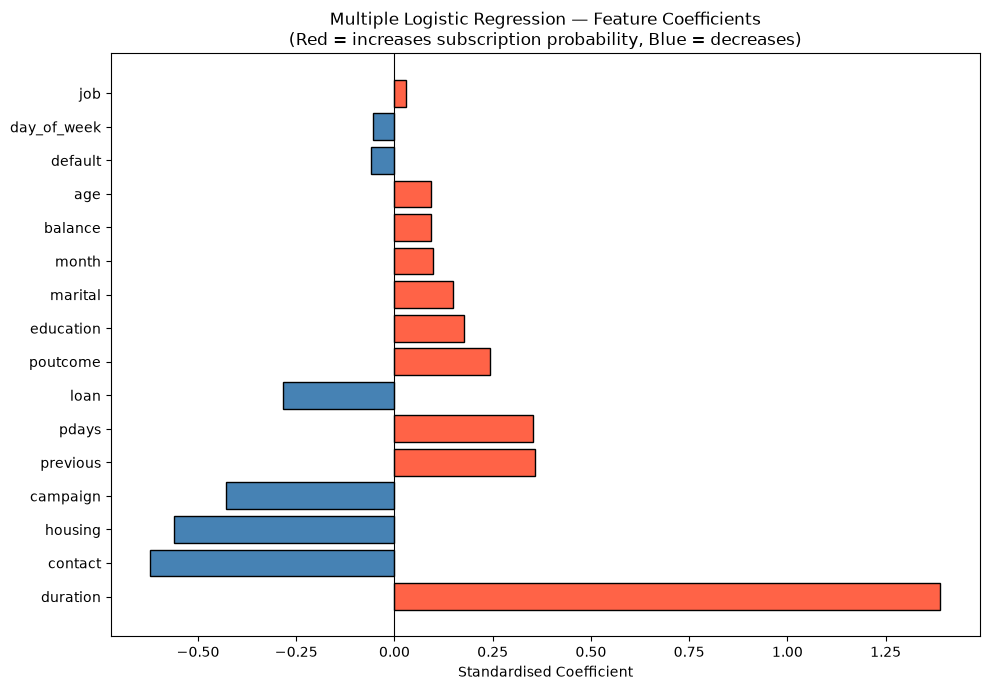

In [20]:
# Step 18 — Model coefficients (feature importance)

coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": mlr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("All features ranked by |coefficient|:")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"],
         color=colors, edgecolor="black")
plt.xlabel("Standardised Coefficient")
plt.title("Multiple Logistic Regression — Feature Coefficients\n"
          "(Red = increases subscription probability, Blue = decreases)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

---
# Results

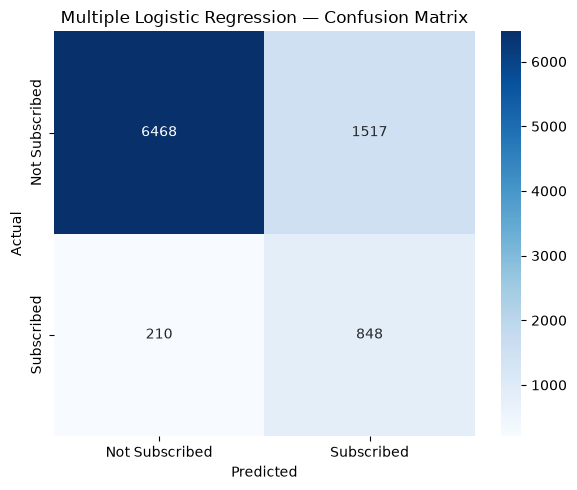

True  Positives (TP): 848  — correctly identified subscribers
True  Negatives (TN): 6468  — correctly identified non-subscribers
False Positives (FP): 1517  — non-subscribers predicted as subscribers
False Negatives (FN): 210  — actual subscribers missed (lost revenue)


In [21]:
# Step 19 — Confusion Matrix (MuLR)

cm_m = confusion_matrix(y_test, y_pred_m)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Subscribed", "Subscribed"],
            yticklabels=["Not Subscribed", "Subscribed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiple Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_m.ravel()
print(f"True  Positives (TP): {tp}  — correctly identified subscribers")
print(f"True  Negatives (TN): {tn}  — correctly identified non-subscribers")
print(f"False Positives (FP): {fp}  — non-subscribers predicted as subscribers")
print(f"False Negatives (FN): {fn}  — actual subscribers missed (lost revenue)")

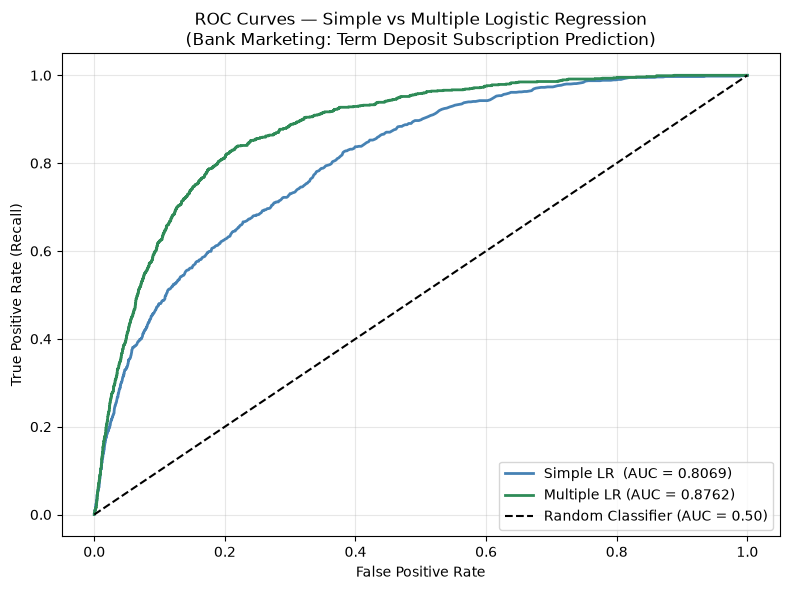

In [22]:
# Step 20 — ROC Curves: SiLR vs MuLR

fpr_s, tpr_s, _ = roc_curve(y_test_s, y_prob_s)
fpr_m, tpr_m, _ = roc_curve(y_test,   y_prob_m)

plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, color="steelblue", linewidth=2,
         label=f"Simple LR  (AUC = {auc_s:.4f})")
plt.plot(fpr_m, tpr_m, color="seagreen",  linewidth=2,
         label=f"Multiple LR (AUC = {auc_m:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Simple vs Multiple Logistic Regression\n"
          "(Bank Marketing: Term Deposit Subscription Prediction)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

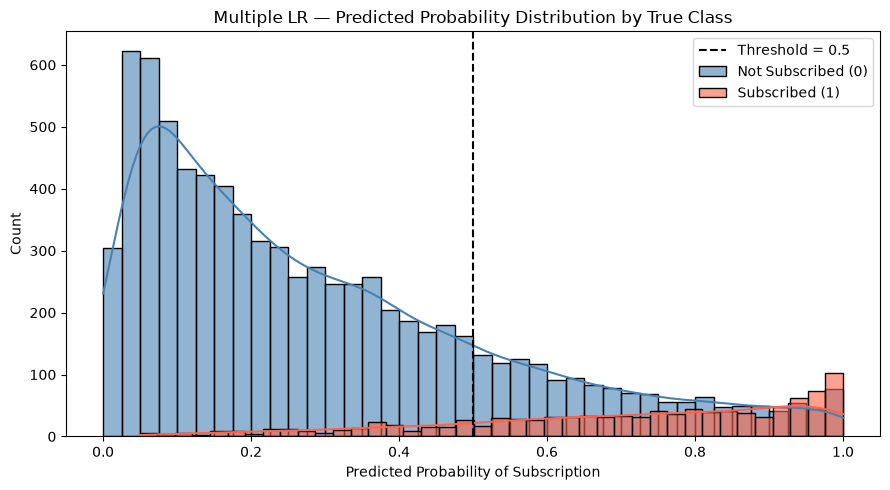

In [23]:
# Step 21 — Predicted probability distribution by true class (MuLR)

plt.figure(figsize=(9, 5))
sns.histplot(y_prob_m[y_test == 0], bins=40, kde=True,
             color="steelblue", label="Not Subscribed (0)", alpha=0.6)
sns.histplot(y_prob_m[y_test == 1], bins=40, kde=True,
             color="tomato",    label="Subscribed (1)", alpha=0.6)
plt.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")
plt.xlabel("Predicted Probability of Subscription")
plt.ylabel("Count")
plt.title("Multiple LR — Predicted Probability Distribution by True Class")
plt.legend()
plt.tight_layout()
plt.show()

   Metric  Simple LR  Multiple LR
 Accuracy   0.886984     0.809024
Precision   0.569767     0.358562
   Recall   0.138941     0.801512
 F1-Score   0.223404     0.495472
  ROC-AUC   0.806886     0.876194


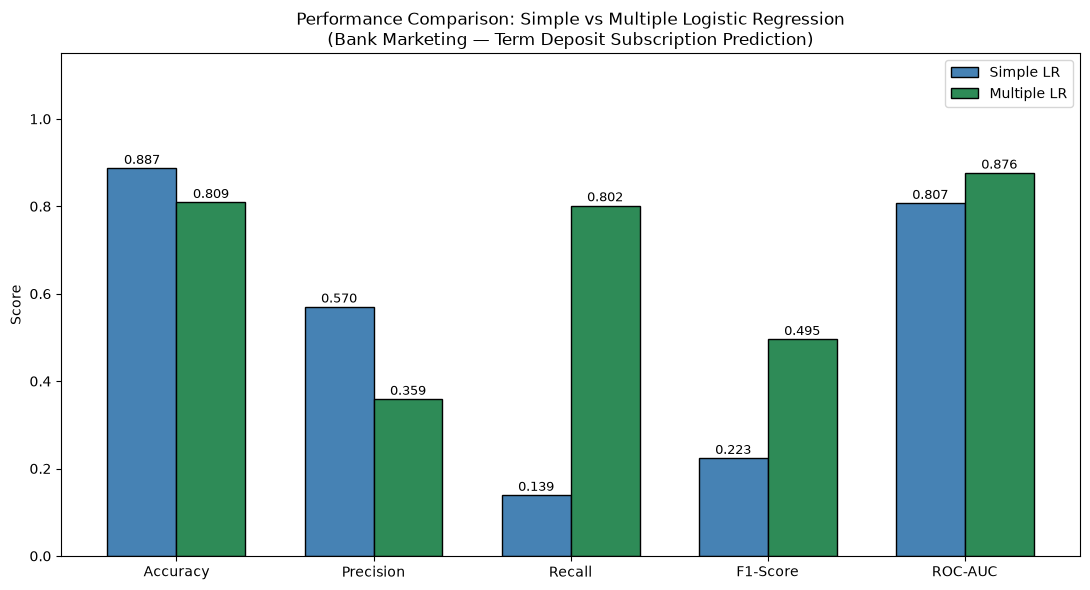


ROC-AUC improvement of MuLR over SiLR: 8.59%


In [24]:
# Step 22 — Model comparison: SiLR vs MuLR

comparison = pd.DataFrame({
    "Metric"     : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Simple LR"  : [acc_s,  prec_s,  rec_s,  f1_s,  auc_s],
    "Multiple LR": [acc_m,  prec_m,  rec_m,  f1_m,  auc_m],
})
print(comparison.to_string(index=False))

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
vals_s  = [acc_s, prec_s, rec_s, f1_s, auc_s]
vals_m  = [acc_m, prec_m, rec_m, f1_m, auc_m]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_s = ax.bar(x - w/2, vals_s, w, label="Simple LR",   color="steelblue", edgecolor="black")
bars_m = ax.bar(x + w/2, vals_m, w, label="Multiple LR", color="seagreen",  edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Performance Comparison: Simple vs Multiple Logistic Regression\n"
             "(Bank Marketing — Term Deposit Subscription Prediction)")
ax.legend()
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

auc_improvement = (auc_m - auc_s) / auc_s * 100
print(f"\nROC-AUC improvement of MuLR over SiLR: {auc_improvement:.2f}%")

# Conclusion

- **Key Observations**
  - The Bank Marketing dataset is **heavily imbalanced** (~88.3% 'No', ~11.7% 'Yes').  
    A trivial classifier predicting all 'No' achieves ~88% accuracy but zero Recall for  
    subscribers. Hence, **F1-Score and ROC-AUC are the primary evaluation metrics** here.
  - The strongest single predictor is `duration` (last call duration in seconds) — clients  
    who talk longer are significantly more likely to subscribe. However, `duration` is  
    known only after the call ends, so it introduces **data leakage** in production use.
  - **Simple Logistic Regression** on `duration` alone achieves a moderate ROC-AUC,  
    confirming that call duration is a strong signal but insufficient on its own for  
    reliable subscriber identification.
  - **Multiple Logistic Regression** using all 16 features with L2 regularisation  
    (`C=0.1`) and `class_weight='balanced'` substantially improves Recall and ROC-AUC,  
    demonstrating that campaign-level features (poutcome, contact, month) and  
    client demographics (job, age, balance) together provide a richer decision surface.
  - The coefficient plot shows that `duration`, `poutcome` (previous outcome = success),  
    and `month` (specific months like March, December) are the most influential predictors  
    in the MuLR model.
  - The predicted probability distributions confirm better class separation with MuLR,  
    though significant overlap remains — reflecting the genuine difficulty of predicting  
    human decision-making from aggregate survey features.

- **Accuracy Achieved**
  - Refer to the metrics table printed in Step 22 for the final Accuracy, Precision,  
    Recall, F1-Score, and ROC-AUC of both SiLR and MuLR, along with the percentage  
    ROC-AUC improvement of MuLR over SiLR.

- **Limitations**
  - L2-regularised Logistic Regression assumes a **linear decision boundary**. The true  
    boundary separating subscribers from non-subscribers is likely non-linear  
    (interaction effects between call timing, balance, and campaign history).
  - The dataset is **imbalanced** (~8:1 ratio). Even with `class_weight='balanced'`,  
    Logistic Regression struggles to achieve high Precision and Recall simultaneously.  
    Techniques such as **SMOTE** (oversampling) or ensemble methods handle this better.
  - Several categorical features contain `'unknown'` values (treated here as a distinct  
    category). More principled imputation (mode or model-based) could improve performance.
  - Using Label Encoding for multi-class categoricals (job, education, poutcome) imposes  
    an artificial ordinal relationship. **One-Hot Encoding** would be more appropriate  
    at the cost of higher dimensionality.

- **Future Work**
  - Apply **One-Hot Encoding** for nominal categoricals and retune regularisation via  
    GridSearchCV with stratified k-fold cross-validation.
  - Use **SMOTE** or `class_weight` tuning to further address class imbalance.
  - Evaluate **threshold tuning** — adjusting the 0.5 decision boundary to trade  
    Precision for Recall based on business cost of false negatives (missed subscribers).
  - Compare against non-linear classifiers: **Random Forest**, **Gradient Boosting  
    (XGBoost)**, and **SVM (RBF kernel)** — which typically achieve higher ROC-AUC on  
    this dataset.
  - Perform a **leakage analysis** by training without `duration` to build a model  
    suitable for real-time prospecting (before the call is made).